RNN - Erro dos pesos computados e usado somente durante a iteração

In [1]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import ipynbname
import math
import matplotlib.cm as cm
import optuna
from optuna.samplers import RandomSampler
from optuna.samplers import TPESampler
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.exceptions import TrialPruned
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl
#from Testing.RTLO import *
from Functions.RLS import *
from Functions.Utils_RTLO import *
from Functions.Graphs import *
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import mean_squared_error as MSE

FileName = ipynbname.name()

df = pd.read_csv(r'Dataset\Dataset_1_NCA_battery_SoH\CY25-05_1-#01.csv')
sig = df['soh'].values

df = pd.read_csv(r'Dataset\Dataset_1_NCA_battery_SoH\CY25-05_1-#02.csv')
sig2 = df['soh'].values

df = pd.read_csv(r'Dataset\Dataset_1_NCA_battery_SoH\CY25-05_1-#03.csv')
sig3 = df['soh'].values

    
def SelSampler(mode='auto'):
    '''mode: auto, random,  tpe'''
    if mode == 'auto':
        sampler = None
    elif mode == 'tpe':
        sampler = optuna.samplers.TPESampler(multivariate=True, constant_linker=True,group=True,n_startup_trials=2000)
    elif mode == 'random':
        sampler=RandomSampler()
    return sampler

c:\Users\Usuário\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
class RTLO:
    def __init__(self, nI,nR,nO,ηS=[0.1,0.1,0.1], τ=10,lr=1e-5):
        np.random.seed(42)
        self.k = 1
        self.j = nI-1
        self.t = np.array([])
        self.ref = None
        self.act = 'relu'
        self.nI, self.nR, self.nO = nI, nR, nO

        self.ηS = np.array(ηS)
        self.τ = τ
        self.ρ = 0.01

        self.xPi = np.zeros(nI)
        self.hP, self.hU, self.hL = [np.zeros(nR) for i in range(3)]

        self.pS = np.zeros((self.nR, self.nR))
        self.qS = np.zeros((self.nR, self.nI))

        self.ΔOS = np.zeros((nO, nR))
        self.ΔRS = np.zeros((nR, nR))
        self.ΔIS = np.zeros((nR, nI))
        
        self.wI = XavierUniform([nR, nI],sd=42)
        self.wR = XavierUniform([nR, nR],sd=41)
        self.wO = XavierUniform([nO, nR],sd=40)
        self.BS = XavierUniform([nR, nO],sd=39)

        self.rls = RLS_LogarithmicRegressor(0.95,1e7)
        
        self.yP, self.yR, self.yL, self.yU = [np.array([]) for i in range(4)]
        self.yP_hist = np.zeros(self.nI)
        self.eS = np.zeros(nI)
        self.eS2 = np.zeros(nI)
        self.eP = np.array([])
        self.eR = np.array([])

        self.εY, self.εM, self.εE, self.εR, self.ΣW = [0 for i in range(5)]
        self.εM_hist = np.array([])
        self.εR_hist = np.array([])

        self.μrWAPE = 0
        self.MPsum = 0

        self.rR = 1e-9
        self.rP = 1e-10
        self.rL = 1e-11
        self.rU = 1e-12
        self.rRsum = 0

        self.rulR, self.rulP, self.rulL, self.rulU = [np.array([]) for i in range(4)]


    def PredSingle(self,x):

        u = np.dot(self.wR, self.hS) + np.dot(self.wI, x)
        h = self.hS + (-self.hS + Activation(u,self.act))/self.τ
        y = np.dot(self.wO, h)

        return y

    def fit(self,xP,yR,store=False,show=False):

        exp=2
        W = self.j**exp
        η1,η2,η3 = self.ηS        
        #print('fit self.hP:',self.hP[-5:])
        uS = self.wR @ self.hP + self.wI @ xP
        #hP = self.hP + (-self.hP + Activation(uS,self.act))/self.τ
        hP = self.hP*(1-1/self.τ) +Activation(uS,self.act)/self.τ
        yP = self.wO @ hP
        eS = yR-yP

        if show: 
            #print('yR:',yR)
            #print('xP:',xP)
            print('fit  yP:',yP[0])
            #print('fit  hP:',self.hP)
            #print('fit  hP2:',hP)
            #print('fit xP:',xP)
            #print('fit uP:',uS)
            #print('fit  wR:\n',self.wR)
            #print('fit  wI\n:',self.wI)
            #print('fit  wO\n:',self.wO)

        self.pS = np.outer(dActivation(uS,self.act),self.hP)/self.τ + (1-1/self.τ)*self.pS
        self.qS = np.outer(dActivation(uS,self.act),self.xPi)/self.τ + (1-1/self.τ)*self.qS

        δOS = η1*np.outer(eS,hP)
        δRS = η2*np.outer((self.BS@eS),np.ones(self.nR))*self.pS
        δIS = η3*np.outer(np.dot(self.BS, eS),np.ones(self.nI))*self.qS

        self.ΔIS = (self.ΔIS*(self.k-1) + δIS)/self.k
        self.ΔRS = (self.ΔRS*(self.k-1) + δRS)/self.k
        self.ΔOS = (self.ΔOS*(self.k-1) + δOS)/self.k

        self.wI = self.wI + δIS
        self.wR = self.wR + δRS
        self.wO = self.wO + δOS

        self.hP = hP
        self.xPi = xP

        #self.UpdateRLS(yP,yR)

        ΣW = self.ΣW + W
        ΔY = np.abs((yR-yP)/yR)
        ΔM = np.linalg.norm(ΔY,ord=2)
        ΔR = np.abs((self.rR-self.rP)/(self.rR+1e-9))
        #ΔE = np.abs((self.eR[-1]-self.eP[-1])/self.eR[-1])

        self.εY = ((self.εY*self.ΣW) + (W*ΔY[0]))/ΣW
        self.εM = ((self.εM*self.ΣW) + (W*ΔM))/ΣW
        self.εR = ((self.εR*self.ΣW) + (W*ΔR))/ΣW
        #self.εE = ((self.εE*self.ΣW) + (W*ΔE))/ΣW
        self.ΣW = ΣW

        if store:
            self.yR = np.append(self.yR,yR[0])
            self.εM_hist = np.append(self.εM_hist,self.εM)
            self.εR_hist = np.append(self.εR_hist,self.εR)

        self.k = self.k+1
        self.j = self.j+1
        self.t = np.append(self.t,self.k + self.nI)
        self.yP_hist = np.delete(np.append(self.yP_hist,yP[0]),0)
        #self.ηS = self.ηS/(1 + self.decay*self.k)


    def PredRulIntr(self, x,lim=0.2,maxRul=110,store=False,show=False):
        #print('yH:',self.yP_hist)
        #print('eS: ',self.eS)

        for i,y in enumerate(self.yP_hist):
            if y != 0:
                self.eS2[i] = self.rls.predict(np.abs(y))
        #print('eS2:',self.eS2)

        xP,xL,xU =x.copy(), (x-(self.ρ*self.eS2)).copy(),(x+(self.ρ*self.eS2)).copy()    

        #xP,xL,xU =x.copy(), x.copy()*0.999, x.copy()*1.00

        predict = True
        PredRuls = [True for i in range(3)]
        PredVals, Ruls = [0 for i in range(3)], [0 for i in range(3)]
        wR,wI,wO = self.wR,self.wI,self.wO

        wRp, wRn = np.maximum(0, self.wR), np.abs(np.minimum(0, self.wR))
        wIp, wIn = np.maximum(0, self.wI), np.abs(np.minimum(0, self.wI))
        wOp, wOn = np.maximum(0, self.wO), np.abs(np.minimum(0, self.wO))
        #hU,hL = np.maximum(0, self.hS), np.minimum(0, self.hS)
        hL,hP,hU = [self.hP.copy() for i in range(3)]

        while predict:
            uP = wR@hP + wI@xP
            uL = (wRp @ hL - wRn @ hU) + (wIp @ xL - wIn @ xU)
            uU = (wRp @ hU - wRn @ hL) + (wIp @ xU - wIn @ xL)

            hP = hP*(1-1/self.τ) + Activation(uP,self.act)/self.τ
            hL = hL*(1-1/self.τ) + Activation(uL,self.act)/self.τ
            hU = hU*(1-1/self.τ) + Activation(uU,self.act)/self.τ
    
            yP = (wO@hP)
            yL = (wOp @ hL - wOn @ hU)
            yU = (wOp @ hU - wOn @ hL)

            #if show: print(yP)
            yP = yP[0]
            yL = yL[0]
            yU = yU[0]

            xP = np.delete(np.append(xP,yP),0)
            xL = np.delete(np.append(xL,yL),0)
            xU = np.delete(np.append(xU,yU),0)
            PredVals = [yL,yP,yU]

            if Ruls[0] == 0:
                self.yL = np.append(self.yL,yL)
                self.yP = np.append(self.yP,yP)
                self.yU = np.append(self.yU,yU)
            
            CheckPred,CheckLim=0,0
            for i in range(3):
                if PredRuls[i]: 
                    Ruls[i] = Ruls[i]+1
                    if Ruls[i] >= maxRul:
                        CheckLim = CheckLim + 1
                        Ruls[i] = maxRul
                        PredRuls[i] = False
                if PredVals[i] < lim: PredRuls[i] = False
                if not PredRuls[i]: CheckPred = CheckPred + 1
            if CheckPred == 3:break
            if CheckLim == 3:break
        
        self.rR=self.ref-self.k
        self.rL,self.rP,self.rU = Ruls

        if store:
            self.rulR = np.append(self.rulR,self.rR)
            self.rulL = np.append(self.rulL,self.rL)
            self.rulP = np.append(self.rulP,self.rP)
            self.rulU = np.append(self.rulU,self.rU)
    
    def PredRulIntr2(self, x,lim=0.2,maxRul=110,store=False,show=False):
        #print('yH:',self.yP_hist)
        #print('eS: ',self.eS)

        for i,y in enumerate(self.yP_hist):
            if y != 0:
                self.eS2[i] = self.rls.predict(np.abs(y))
        #print('eS2:',self.eS2)

        xP,xL,xU =x.copy(), (x-(self.ρ*self.eS2)).copy(),(x+(self.ρ*self.eS2)).copy()    

        #xP,xL,xU =x.copy(), x.copy()*0.999, x.copy()*1.00

        predict = True
        PredRuls = [True for i in range(3)]
        PredVals, Ruls = [0 for i in range(3)], [0 for i in range(3)]
        wR,wI,wO = self.wR,self.wI,self.wO
        ep = 0.125
        wRp, wRn = np.maximum((1+ep)*wR, (1-ep)*wR), np.minimum((1+ep)*wR, (1-ep)*wR)

        print('wRn',wRn[0][:5])
        print('wR ',wR[0][:5])
        print('wRp',wRp[0][:5])
        print('---')

        wIp, wIn = np.maximum((1+ep)*wI, (1-ep)*wI), np.minimum((1+ep)*wI, (1-ep)*wI)
        wOp, wOn = np.maximum((1+ep)*wO, (1-ep)*wO), np.minimum((1+ep)*wO, (1-ep)*wO)

        #hU,hL = np.maximum(0, self.hS), np.minimum(0, self.hS)
        #hL,hP,hU = (1-ep)*self.hP.copy(),self.hP.copy(),(1+ep)*self.hP.copy()  
        hP = self.hP.copy()  
        hU, hL = np.maximum((1+ep)*hP, (1-ep)*hP), np.minimum((1+ep)*hP, (1-ep)*hP)

        while predict:
            uP = wR@hP + wI@xP
            uL = (wRn @ hL) + (wIn @ xL)
            uU = (wRp @ hU) + (wIp @ xU)

            hP = hP*(1-1/self.τ) + Activation(uP,self.act)/self.τ
            hL = hL*(1-1/self.τ) + Activation(uL,self.act)/self.τ
            hU = hU*(1-1/self.τ) + Activation(uU,self.act)/self.τ
    
            yP = (wO@hP)[0]
            yL = (wOn @ hL)[0]
            yU = (wOp @ hU)[0]

            PredVals = sorted([yL,yP,yU])

            yL,yP,yU = PredVals

            xP = np.delete(np.append(xP,yP),0)
            xL = np.delete(np.append(xL,yL),0)
            xU = np.delete(np.append(xU,yU),0)

            if Ruls[0] == 0:
                self.yL = np.append(self.yL,yL)
                self.yP = np.append(self.yP,yP)
                self.yU = np.append(self.yU,yU)
            
            CheckPred,CheckLim=0,0
            for i in range(3):
                if PredRuls[i]: 
                    Ruls[i] = Ruls[i]+1
                    if Ruls[i] >= maxRul:
                        CheckLim = CheckLim + 1
                        Ruls[i] = maxRul
                        PredRuls[i] = False
                if PredVals[i] < lim: PredRuls[i] = False
                if not PredRuls[i]: CheckPred = CheckPred + 1
            if CheckPred == 3:break
            if CheckLim == 3:break
        
        self.rR=self.ref-self.k
        self.rL,self.rP,self.rU = Ruls

        if store:
            self.rulR = np.append(self.rulR,self.rR)
            self.rulL = np.append(self.rulL,self.rL)
            self.rulP = np.append(self.rulP,self.rP)
            self.rulU = np.append(self.rulU,self.rU)
    
    def PredRulIntr3(self, x,lim=0.2,maxRul=110,store=False,show=False):
        
        xP,xL,xU =x.copy(), x.copy(), x.copy()
        k = 1
        predict = True
        PredRuls = [True for i in range(3)]
        PredVals, Ruls = [0 for i in range(3)], [0 for i in range(3)]
        wR,wI,wO = self.wR,self.wI,self.wO
        hP = self.hP.copy() 
        ep = 1+self.ρ

        wRU, wRL = np.maximum(ep*wR, wR/ep), np.minimum(ep*wR, wR/ep)
        wIU, wIL = np.maximum(ep*wI, wI/ep), np.minimum(ep*wI, wI/ep)
        wOU, wOL = np.maximum(ep*wO, wO/ep), np.minimum(ep*wO, wO/ep) 
        hU ,  hL = np.maximum(ep*hP, hP/ep), np.minimum(ep*hP, hP/ep)

        '''ep=self.ρ

        wRU, wRL = np.maximum((1+ep)*wR, (1-ep)*wR), np.minimum((1+ep)*wR, (1-ep)*wR)
        wIU, wIL = np.maximum((1+ep)*wI, (1-ep)*wI), np.minimum((1+ep)*wI, (1-ep)*wI)
        wOU, wOL = np.maximum((1+ep)*wO, (1-ep)*wO), np.minimum((1+ep)*wO, (1-ep)*wO)
        hU, hL = np.maximum((1+ep)*hP, (1-ep)*hP), np.minimum((1+ep)*hP, (1-ep)*hP)'''

        while predict:
            uP = ( wR @ hP) + ( wI @ xP)
            uL = (wRL @ hL) + (wIL @ xL)
            uU = (wRU @ hU) + (wIU @ xU)

            #uU, uL = np.maximum(uU,uL), np.minimum(uU,uL)
            
            hP = hP*(1-1/self.τ) + Activation(uP,self.act)/self.τ
            hL = hL*(1-1/self.τ) + Activation(uL,self.act)/self.τ
            hU = hU*(1-1/self.τ) + Activation(uU,self.act)/self.τ

            hU,hL= hP,hP
            #hU, hL = np.maximum(hU,hL), np.minimum(hU,hL)

            yP = ( wO @ hP)
            yL = (wOL @ hL)
            yU = (wOU @ hU)
            yU, yL = np.maximum(yU,yL), np.minimum(yU,yL)

            
            PredVals = ([yL[0],yP[0],yU[0]])
            yL,yP,yU = PredVals

            xP = np.delete(np.append(xP,yP),0)
            xL = np.delete(np.append(xL,yL),0)
            xU = np.delete(np.append(xU,yU),0)

            if Ruls[0] == 0:
                self.yL = np.append(self.yL,yL)
                self.yP = np.append(self.yP,yP)
                self.yU = np.append(self.yU,yU)
            
            CheckPred,CheckLim=0,0
            for i in range(3):
                if PredRuls[i]: 
                    Ruls[i] = Ruls[i]+1
                    if Ruls[i] >= maxRul:
                        CheckLim = CheckLim + 1
                        Ruls[i] = maxRul
                        PredRuls[i] = False
                if PredVals[i] < lim: PredRuls[i] = False
                if not PredRuls[i]: CheckPred = CheckPred + 1
            if CheckPred == 3:break
            if CheckLim == 3:break
            k = k+1
        self.rR=self.ref-self.k
        self.rL,self.rP,self.rU = Ruls

        if store:
            self.rulR = np.append(self.rulR,self.rR)
            self.rulL = np.append(self.rulL,self.rL)
            self.rulP = np.append(self.rulP,self.rP)
            self.rulU = np.append(self.rulU,self.rU)
    

    def PredRul(self, x,maxRul=100,lim=0.2,store=False):
        xP = x.copy()
        rulP=0
        predict = True
        hP = self.hP.copy()
        while predict:
            uP = (self.wR @ hP) + (self.wI @ xP)
            hP = hP*(1-1/self.τ) + Activation(uP,self.act)/self.τ
            yP = (self.wO @ hP)[0]
            xP = np.delete(np.append(xP,yP),0)
            if store:
                if rulP==0:
                    self.yP = np.append(self.yP,yP)

            if predict: rulP = rulP+1
            if yP < lim: predict = False
            if rulP >= maxRul:
                break

        self.rR=self.ref-self.k
        self.rP = rulP

        if store:
            self.rulR = np.append(self.rulR,self.rR)
            self.rulP = np.append(self.rulP,self.rP)
            
    
    def UpdateRLS(self,yP,yR):
        eP = np.abs(self.rls.predict(np.abs(yP[0])))
        eR = np.abs(yP-yR)[0]
        self.rls.update(np.abs(yP[0]), eR)
        self.eR = np.append(self.eR,eR)
        self.eP = np.append(self.eP,eP)
        self.eS = np.append(self.eS,eP)
        self.eS = np.delete(self.eS,0)


#Optimize parameters for minimize error of degradation prediction

In [28]:
rates = [1/(10**i) for i in range(1,7)][::-1]
def objective(trial):

    nI = trial.suggest_int('nI', 2, 30) 
    nR = trial.suggest_int('nR', 1, 50) 
    nO = trial.suggest_int('nO', 1, 10) 
    N1 = trial.suggest_categorical('N1', rates[:]) 
    N2 = trial.suggest_categorical('N2', rates[:]) 
    N3 = trial.suggest_categorical('N3', rates[:]) 
    τ = trial.suggest_int('τ', 1, 30)        
    X,Y = PrepareDataAhead(sig,n=nI,m=nO)
    X,Y = X[:-1],Y[:-1]
    rnn = RTLO(nI,nR,nO,[N1,N2,N3],τ)
    rnn.ref = len(sig)-nI
    cont = 0
    for i,_ in enumerate(X):
        rnn.PredRul(X[i],maxRul=len(sig)-nI,lim=0.75,store=True)
        rnn.fit(X[i],Y[i],store=True)

        '''if i == 50:
            if np.mean(rnn.εM_hist)>1:
                raise TrialPruned()
            if np.mean(rnn.rulP)>np.mean(rnn.rulR)*1.1:
                raise TrialPruned()
            if np.mean(rnn.rulP)<np.mean(rnn.rulR)*0.3:
                raise TrialPruned()
        if i>=40:
            if rnn.rulP[i]==rnn.rulP[i-1]:
                cont = cont+1
            if cont> 20:
                raise TrialPruned()'''
            
    return rnn.εM+rnn.εR

#pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
pruner=optuna.pruners.HyperbandPruner()

study = optuna.create_study(
    direction="minimize",
    sampler=SelSampler(mode='random'),
    pruner=pruner,
    #storage="sqlite:///" + f'Optuna/{FileName}_Prdct.db', study_name=f'P{4}',
    load_if_exists=True)
study.optimize(objective, n_trials=10000)
params = list(study.best_params.values())
print('Erro:', study.best_value, 'parameters: ', params)

[I 2026-04-23 14:58:14,755] A new study created in memory with name: no-name-6a378f39-8532-44e5-8e13-d7f850518553
[I 2026-04-23 14:58:14,765] Trial 0 finished with value: 2.573423008397281 and parameters: {'nI': 12, 'nR': 12, 'nO': 6, 'N1': 1e-05, 'N2': 1e-05, 'N3': 0.001, 'τ': 26}. Best is trial 0 with value: 2.573423008397281.
[I 2026-04-23 14:58:14,777] Trial 1 finished with value: 2.025864405863426 and parameters: {'nI': 6, 'nR': 37, 'nO': 4, 'N1': 1e-05, 'N2': 1e-05, 'N3': 0.0001, 'τ': 12}. Best is trial 1 with value: 2.025864405863426.
[I 2026-04-23 14:58:14,784] Trial 2 finished with value: 2.1629819034945994 and parameters: {'nI': 5, 'nR': 44, 'nO': 4, 'N1': 1e-05, 'N2': 1e-05, 'N3': 0.001, 'τ': 22}. Best is trial 1 with value: 2.025864405863426.
[I 2026-04-23 14:58:14,797] Trial 3 finished with value: 0.9428254261433733 and parameters: {'nI': 8, 'nR': 5, 'nO': 1, 'N1': 0.0001, 'N2': 0.01, 'N3': 1e-06, 'τ': 29}. Best is trial 3 with value: 0.9428254261433733.
[I 2026-04-23 14:5

Erro: 0.00028172699674651534 parameters:  [3, 13, 2, 0.1, 0.001, 1e-05, 1]


Erro: 0.00048766868214013016 parameters:  [5, 48, 1, 0.1, 1e-06, 0.1, 9]\
Erro: 0.0004731207146124864 parameters:  [9, 12, 1, 1e-06, 0.01, 0.1, 1]\
Erro: 0.0003514928586813473 parameters:  [10, 38, 1, 0.1, 1e-06, 1e-05, 5]\
Erro: 0.0002067700572095104 parameters:  [3, 38, 1, 0.1, 0.001, 1e-06, 1]\
Erro: 0.00014817900818612473 parameters:  [3, 13, 1, 0.1, 0.1, 0.01, 1]\
\









In [80]:
rates = [1/(10**i) for i in range(1,8)][::-1]
def objective(trial):

    nI = trial.suggest_int('nI', 10, 30) 
    nR = trial.suggest_int('nR', 25, 45) 
    nO = trial.suggest_int('nO', 5, 30) 
    N1 = trial.suggest_categorical('N1', rates[2:]) 
    N2 = trial.suggest_categorical('N2', rates[:-2]) 
    N3 = trial.suggest_categorical('N3', rates[:-2]) 
    τ = trial.suggest_int('τ', 5, 30)           
    X,Y = PrepareDataAhead(sig,n=nI,m=nO)
    X,Y = X[:-1], Y[:-1]
    rnn = RTLO(nI,nR,nO,[N1,N2,N3],τ)
    rnn.ref = len(sig)-nI

    for i,_ in enumerate(X):
        rnn.PredRul(X[i],maxRul=len(sig)-nI,lim=0.75,store=True)
        rnn.fit(X[i],Y[i],store=True)

        if i == int((len(sig)-nI)/2):
            #if np.mean(rnn.εM_hist)>1:
            #    raise TrialPruned()
            if np.mean(rnn.rulP)>np.mean(rnn.rulR)*1.25:
                raise TrialPruned()
            if np.mean(rnn.rulP)<np.mean(rnn.rulR)*0.25:
                raise TrialPruned()
            
    return rnn.εM, rnn.εR

#pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
pruner=optuna.pruners.HyperbandPruner()

study = optuna.create_study(
    directions=["minimize", "minimize"],
    sampler=SelSampler(mode='auto'),
    #pruner=pruner,
    #storage="sqlite:///" + f'Optuna/{FileName}_Prdct.db', study_name=f'P{4}',
    load_if_exists=True)
study.optimize(objective, n_trials=3000)

best_trials = study.best_trials

print(f"Encontrados {len(best_trials)} modelos na Fronteira de Pareto:")

for i, trial in enumerate(best_trials):
    print(f"Erro_M = {trial.values[0]:.6f}, Erro_R = {trial.values[1]:.6f}",
          f"Parâmetros: {trial.params}")
# Se você quiser apenas os parâmetros do PRIMEIRO modelo da fronteira para testar:
first_best_params = best_trials[0].params
params = list(trial.params.values())


[I 2026-04-23 16:32:06,193] A new study created in memory with name: no-name-0c7fb408-9d8d-48a4-a3a2-a815cd32c808
[I 2026-04-23 16:32:06,210] Trial 0 pruned. 
[I 2026-04-23 16:32:06,299] Trial 1 finished with values: [0.1993010341051441, 1.5842520662572217] and parameters: {'nI': 12, 'nR': 40, 'nO': 12, 'N1': 0.01, 'N2': 0.001, 'N3': 1e-07, 'τ': 15}.
[I 2026-04-23 16:32:06,305] Trial 2 pruned. 
[I 2026-04-23 16:32:06,402] Trial 3 finished with values: [0.24096968442048042, 1.3959769709541343] and parameters: {'nI': 26, 'nR': 29, 'nO': 27, 'N1': 0.01, 'N2': 1e-07, 'N3': 1e-05, 'τ': 7}.
[I 2026-04-23 16:32:06,448] Trial 4 finished with values: [0.017749287164758272, 0.5884648354230122] and parameters: {'nI': 21, 'nR': 29, 'nO': 7, 'N1': 0.1, 'N2': 0.001, 'N3': 0.001, 'τ': 11}.
[I 2026-04-23 16:32:06,456] Trial 5 pruned. 
[I 2026-04-23 16:32:06,522] Trial 6 finished with values: [0.04156637699439073, 0.4159531965435908] and parameters: {'nI': 21, 'nR': 37, 'nO': 15, 'N1': 0.1, 'N2': 1e-05

Encontrados 285 modelos na Fronteira de Pareto:
Erro_M = 0.005953, Erro_R = 0.364375 Parâmetros: {'nI': 12, 'nR': 43, 'nO': 5, 'N1': 0.1, 'N2': 0.001, 'N3': 1e-07, 'τ': 7}
Erro_M = 0.009070, Erro_R = 0.264836 Parâmetros: {'nI': 18, 'nR': 34, 'nO': 5, 'N1': 0.1, 'N2': 0.0001, 'N3': 1e-07, 'τ': 7}
Erro_M = 0.005953, Erro_R = 0.364608 Parâmetros: {'nI': 12, 'nR': 43, 'nO': 5, 'N1': 0.1, 'N2': 0.001, 'N3': 0.0001, 'τ': 7}
Erro_M = 0.005953, Erro_R = 0.364375 Parâmetros: {'nI': 12, 'nR': 43, 'nO': 5, 'N1': 0.1, 'N2': 0.001, 'N3': 1e-07, 'τ': 7}
Erro_M = 0.004207, Erro_R = 0.511435 Parâmetros: {'nI': 14, 'nR': 41, 'nO': 5, 'N1': 0.1, 'N2': 0.001, 'N3': 0.001, 'τ': 5}
Erro_M = 0.009088, Erro_R = 0.260267 Parâmetros: {'nI': 18, 'nR': 34, 'nO': 5, 'N1': 0.1, 'N2': 0.001, 'N3': 1e-07, 'τ': 7}
Erro_M = 0.048903, Erro_R = 0.088563 Parâmetros: {'nI': 18, 'nR': 28, 'nO': 21, 'N1': 0.1, 'N2': 0.0001, 'N3': 0.0001, 'τ': 14}
Erro_M = 0.004637, Erro_R = 0.455209 Parâmetros: {'nI': 14, 'nR': 41, 'nO': 5,

Erro_M = 0.055991, Erro_R = 0.097426 Parâmetros: {'nI': 18, 'nR': 26, 'nO': 18, 'N1': 0.1, 'N2': 1e-05, 'N3': 1e-07, 'τ': 13}\
Erro_M = 0.069533, Erro_R = 0.093981 Parâmetros: {'nI': 18, 'nR': 26, 'nO': 25, 'N1': 0.1, 'N2': 1e-05, 'N3': 0.001, 'τ': 13}\
Erro_M = 0.030335, Erro_R = 0.090408 Parâmetros: {'nI': 18, 'nR': 34, 'nO': 26, 'N1': 0.1, 'N2': 1e-07, 'N3': 0.001, 'τ': 7}\
Erro_M = 0.048903, Erro_R = 0.088563 Parâmetros: {'nI': 18, 'nR': 28, 'nO': 21, 'N1': 0.1, 'N2': 0.0001, 'N3': 0.0001, 'τ': 14}\
Erro_M = 0.048906, Erro_R = 0.081153 Parâmetros: {'nI': 18, 'nR': 28, 'nO': 21, 'N1': 0.1, 'N2': 0.001, 'N3': 0.0001, 'τ': 14}


In [3]:
params= {'nI': 18, 'nR': 28, 'nO': 21, 'N1': 0.1, 'N2': 0.001, 'N3': 0.0001, 'τ': 14}
params = list(params.values())
#params = [8, 41, 1, 0.1, 0.01, 0.001, 2]


0.04983374082868134 0.07962594293589974


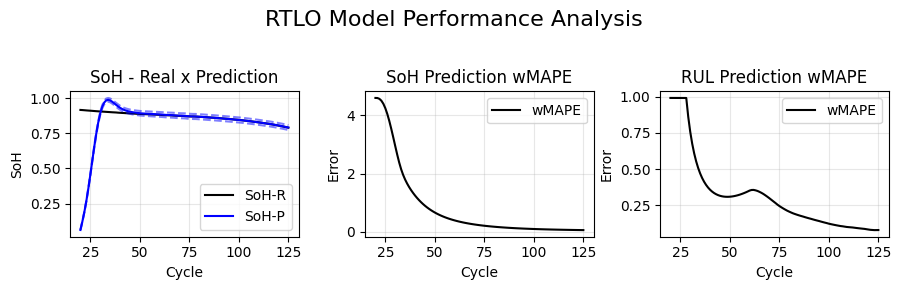

In [73]:
nI,nR,nO,N1,N2,N3,τ= params
X,Y = PrepareDataAhead(sig,n=nI,m=nO)
X,Y = X[:-1],Y[:-1]
rnn = RTLO(nI,nR,nO,[N1,N2,N3],τ)
rnn.ref = len(sig)-nI
for i in range(len(X[:])):
    #rnn.PredRul(x=X[i],store=True,maxRul=len(sig)-nI,lim=0.75)
    rnn.PredRulIntr3(x=X[i],maxRul=len(sig)-nI,lim=0.75,store=True,show=False)
    rnn.fit(X[i],Y[i],store=True,show=False)
#print(.wR[0])
print(rnn.εM,rnn.εR)  
PlotPredErrorMPL(rnn)


In [72]:
def PlotPredErrorMPL(rtlo, w=9, h=3):
    # Definindo o tamanho em polegadas (w e h no MPL são diferentes de pixels no Plotly)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(w, h), sharex=True)
    
    t = rtlo.t
    tol = 0.25
    # --- Subplot 1: Y Real x Pred (com Intervalos) ---
    ax1.plot(t, rtlo.yR, color='black', label='SoH-R')
    ax1.plot(t, rtlo.yP, color='blue', label='SoH-P')
    # Intervalos (Dashed)
    ax1.plot(t, rtlo.yL, color='blue', linestyle='--', alpha=0.5)
    ax1.plot(t, rtlo.yU, color='blue', linestyle='--', alpha=0.5)
    ax1.set_title('SoH - Real x Prediction')
    ax1.set_ylabel('SoH')
    #ax1.set_xlim(20, 130)
    #ax1.set_ylim(0.75, 1)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Subplot 2: RUL - Real x Pred ---
    #ax2.fill_between(t, (1 - tol / 100) * rtlo.rulR, (1 + tol / 100) * rtlo.rulR,
    #                color='gray', alpha=0.75, label=f"T-{tol}%", )
    t_err = t[-len(rtlo.εM_hist):]
    ax2.plot(t_err, rtlo.εM_hist, color='black', label='wMAPE')
    ax2.set_title('SoH Prediction wMAPE')
    ax2.set_ylabel('Error')
    #ax2.set_xlim(20, 130)
    #ax2.set_ylim(0, 1.2)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    #ax2.grid(True, alpha=0.3)

    # --- Subplot 3: RUL Prediction WAPE ---
    # Ajustando o tempo para o tamanho do histórico de erro
    t_err = t[-len(rtlo.εR_hist):]
    ax3.plot(t_err, rtlo.εR_hist, color='black', label='wMAPE')
    ax3.set_title('RUL Prediction wMAPE')
    ax3.set_ylabel('Error')
    #ax3.set_xlim(20, 130)
    #ax3.set_ylim(0, 1)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # --- Ajustes Gerais ---
    fig.suptitle('RTLO Model Performance Analysis', fontsize=16)
    for ax in [ax1, ax2, ax3]:
        ax.set_xlabel('Cycle')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para o título não sobrepor
    plt.show()

In [5]:
rnn2 = RTLO(nI,nR,nO,[N1,N2,N3],τ)
rnn2.ref = len(sig2)-nI
rnn2.wI,rnn2.wR,rnn2.wO = rnn.wI,rnn.wR,rnn.wO
X,Y = PrepareDataAhead(sig2,n=nI,m=nO)
X,Y = X[:-1],Y[:-1]
for i in range(len(X[:])):
    rnn2.PredRul(x=X[i],store=True,maxRul=len(sig2)-nI,lim=0.75)
    #rnn.PredRulIntr2(x=X[i],maxRul=len(sig)-nI,store=True,show=False)
    rnn2.fit(X[i],Y[i],store=True,show=False)
#print(.wR[0])
print(rnn2.εM,rnn2.εR)  
PlotPredErrorPLY(rnn2)

0.01986725705632711 0.29863389655587974


In [98]:
rnn3 = RTLO(nI,nR,nO,[N1,N2,N3],τ)
rnn3.ref = len(sig3)-nI
rnn3.wI,rnn3.wR,rnn3.wO= rnn2.wI,rnn2.wR,rnn2.wO
X,Y = PrepareDataAhead(sig3,n=nI,m=nO)
X,Y = X[:-1],Y[:-1]
for i in range(len(X[:])):
    rnn3.PredRul(x=X[i],store=True,maxRul=len(sig3)-nI,lim=0.75)
    #rnn.PredRulIntr2(x=X[i],maxRul=len(sig)-nI,store=True,show=False)
    rnn3.fit(X[i],Y[i],store=True,show=False)
#print(.wR[0])
print(rnn3.εM,rnn3.εR)  
PlotPredErrorPLY(rnn3)

0.014482836983517388 0.577811203094868


In [7]:
i=50
r_m = np.mean(rnn.rulR[:i])
r_mL = np.mean(rnn.rulR[:i])*0.3
r_mU = np.mean(rnn.rulR[:i])*1.05
p_m = (np.mean(rnn.rulP[:i]))

print('lower:',r_mL,'mid:',r_m,'upper:',r_mU)
print('pred:',p_m)

lower: 28.65 mid: 95.5 upper: 100.275
pred: 86.14


In [486]:
#params =  [14, 8, 14, 0.001, 0.01, 1e-06, 1e-07, 29]
nI,nR,nO,N1,N2,N3,τ= params
ηS = [N1,N2,N3]
X,Y = PrepareDataAhead(sig,n=nI,m=nO)
rnn = RTLO(nI,nR,nO,ηS,τ)
rnn.ref = len(sig)-nI

i=0

In [488]:
#rnn.PredRul(x=X[i],store=True)
print('iteration:',i)
print('xP:',X[i])
print('yR:',Y[i])
rnn.PredRulIntr2(x=X[i],store=True,show=True)
rnn.fit(X[i],Y[i],store=True,show=False)
i=i+1

iteration: 1
xP: [0.91429178 0.91121962 0.90817817 0.90519636 0.90227154 0.89941598]
yR: [0.89663373 0.8939275  0.89128272 0.88870303 0.88617045 0.88366572]
[np.float64(-0.03730620483456837), np.float64(-0.04602629367076666), np.float64(-0.05561926571854693)]


In [496]:
v = [np.float64(-0.03730620483456837), np.float64(-0.04602629367076666), np.float64(-0.05561926571854693)]
v = sorted(v)
print(v)

[np.float64(-0.05561926571854693), np.float64(-0.04602629367076666), np.float64(-0.03730620483456837)]
